# Integrals - Python Implementation

This notebook provides a comprehensive, hands-on guide to **integrals** using Python, NumPy, SymPy, SciPy, and Pandas.

## Why Integrals Matter in AI/ML

Integrals are the mathematical language of **accumulation**. They help us measure:

- **Area under curves** (loss landscapes, ROC curves)
- **Expected values** (average reward in RL, model predictions)
- **Probability distributions** (normalizing PDFs, computing probabilities)
- **Continuous learning systems** (Neural ODEs, diffusion models)

> **Key Insight:** If derivatives tell us how things *change*, integrals tell us how things *accumulate*.

## Libraries Used

- `sympy` — Symbolic mathematics (exact integrals)
- `numpy` — Numerical arrays and operations
- `scipy.integrate` — Numerical integration methods
- `pandas` — Data organization and comparison tables
- `matplotlib` — Visualization

Let's begin!

In [1]:
import numpy as np
import sympy as sp
from sympy import symbols, integrate, diff, sin, cos, exp, log, oo, pi, sqrt, Rational, simplify
from scipy import integrate as sci_integrate
import pandas as pd
import matplotlib.pyplot as plt

# Configure SymPy for pretty printing
sp.init_printing()

print("All libraries imported successfully!")

All libraries imported successfully!


---

# Section 1: Introduction to Integration

## Concept

Integration is the **reverse operation** of differentiation. If we know the rate of change of a quantity, integration allows us to recover the original quantity.

## Mathematical Formula

$$\int f(x) \, dx = F(x) + C$$

where $F'(x) = f(x)$ and $C$ is the constant of integration.

## AI/ML Connection

In machine learning, integration helps us:
- Compute total error (area under loss curves)
- Normalize probability distributions
- Compute cumulative rewards in reinforcement learning

## Example Functions

Let's define simple functions and explore their antiderivatives.

Function 1: x**2
Function 2: x**3
Function 3: 3*x**2 + 5*x + 2


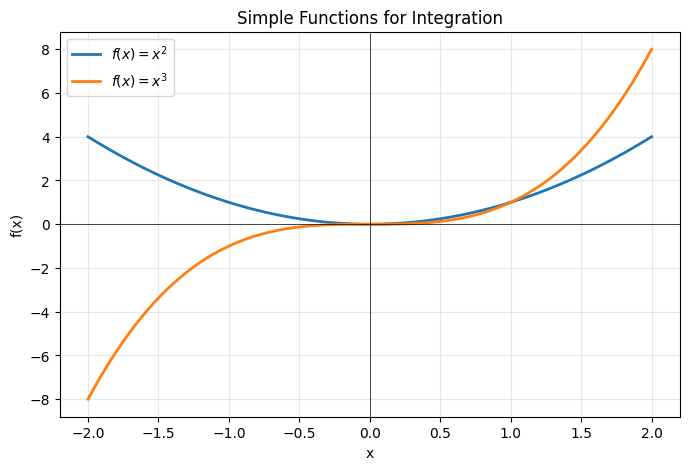

In [2]:
# Define symbolic variable
x = symbols('x')

# Define simple functions
f1 = x**2
f2 = x**3
f3 = 3*x**2 + 5*x + 2

print("Function 1:", f1)
print("Function 2:", f2)
print("Function 3:", f3)

# Visualize the functions
x_vals = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(x_vals, x_vals**2, label=r'$f(x) = x^2$', linewidth=2)
ax.plot(x_vals, x_vals**3, label=r'$f(x) = x^3$', linewidth=2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Simple Functions for Integration')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 2: Antiderivatives using SymPy

## Concept

An **antiderivative** of a function $f(x)$ is a function $F(x)$ such that $F'(x) = f(x)$. SymPy's `integrate()` function computes symbolic antiderivatives exactly.

## Mathematical Formulas

$$\int x^2 \, dx = \frac{x^3}{3} + C$$

$$\int x^4 \, dx = \frac{x^5}{5} + C$$

$$\int (3x^2 + 5x + 2) \, dx = x^3 + \frac{5x^2}{2} + 2x + C$$

## Python Implementation

We use `sympy.integrate()` to find antiderivatives symbolically.

In [3]:
# Compute antiderivatives using SymPy
F1 = integrate(x**2, x)
F2 = integrate(x**4, x)
F3 = integrate(3*x**2 + 5*x + 2, x)

print("Antiderivative of x^2:", F1)
print("Antiderivative of x^4:", F2)
print("Antiderivative of 3x^2 + 5x + 2:", F3)

# Display in LaTeX-style format
print("\n--- LaTeX Output ---")
sp.pprint(F1)
sp.pprint(F2)
sp.pprint(F3)

Antiderivative of x^2: x**3/3
Antiderivative of x^4: x**5/5
Antiderivative of 3x^2 + 5x + 2: x**3 + 5*x**2/2 + 2*x

--- LaTeX Output ---
 3
x 
──
3 
 5
x 
──
5 
        2      
 3   5⋅x       
x  + ──── + 2⋅x
      2        


---

# Section 3: Verify Differentiation and Integration

## Concept

The **Fundamental Theorem of Calculus** tells us that differentiation and integration are inverse operations (up to a constant). If we integrate and then differentiate, we should recover the original function.

## Mathematical Formula

$$\frac{d}{dx} \left( \int f(x) \, dx \right) = f(x)$$

## Example

For $f(x) = x^3$:
- Integrate: $\int x^3 \, dx = \frac{x^4}{4} + C$
- Differentiate: $\frac{d}{dx} \left( \frac{x^4}{4} + C \right) = x^3$ ✓

## AI/ML Connection

In automatic differentiation (used in PyTorch/TensorFlow), understanding this inverse relationship is crucial for backpropagation and gradient-based optimization.

In [4]:
# Verify: integrate then differentiate
f_original = x**3
F = integrate(f_original, x)  # Antiderivative
f_recovered = diff(F, x)      # Differentiate back

print("Original function:", f_original)
print("After integration:", F)
print("After differentiation:", f_recovered)
print("Match?", simplify(f_recovered - f_original) == 0)

# Verify for sin(x)
f_sin = sin(x)
F_sin = integrate(f_sin, x)
f_sin_recovered = diff(F_sin, x)

print("\n--- sin(x) ---")
print("Original:", f_sin)
print("Integrated:", F_sin)
print("Differentiated back:", f_sin_recovered)
print("Match?", simplify(f_sin_recovered - f_sin) == 0)

Original function: x**3
After integration: x**4/4
After differentiation: x**3
Match? True

--- sin(x) ---
Original: sin(x)
Integrated: -cos(x)
Differentiated back: sin(x)
Match? True


---

# Section 4: Indefinite Integrals

## Concept

An **indefinite integral** represents the family of all antiderivatives of a function. The result always includes $+C$ (constant of integration) because the derivative of any constant is zero.

## Mathematical Formulas

$$\int x^2 \, dx = \frac{x^3}{3} + C$$

$$\int x^5 \, dx = \frac{x^6}{6} + C$$

$$\int \sin(x) \, dx = -\cos(x) + C$$

$$\int e^x \, dx = e^x + C$$

## Output Interpretation

Each result represents infinitely many functions (differing by a constant $C$) whose derivative equals the integrand.

∫ x^2 dx = x**3/3 + C
∫ x^5 dx = x**6/6 + C
∫ sin(x) dx = -cos(x) + C
∫ e^x dx = exp(x) + C
∫ 1/x dx = log(x) + C


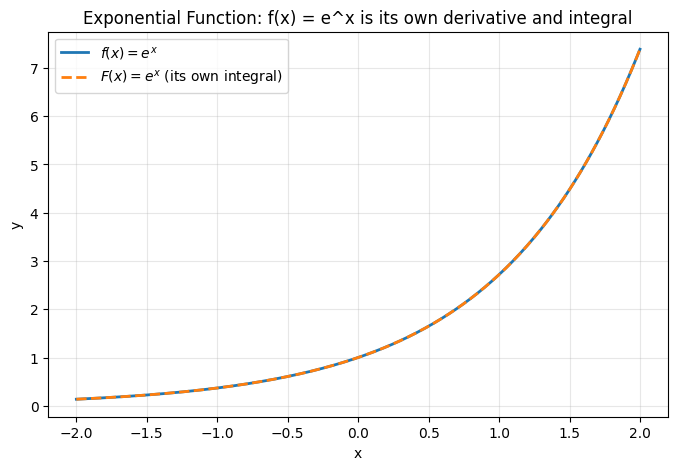

In [5]:
# Compute indefinite integrals
integrals = {
    'x^2': integrate(x**2, x),
    'x^5': integrate(x**5, x),
    'sin(x)': integrate(sin(x), x),
    'e^x': integrate(exp(x), x),
    '1/x': integrate(1/x, x),
}

for func_name, result in integrals.items():
    print(f"∫ {func_name} dx = {result} + C")

# Visualize e^x and its integral
x_vals = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(x_vals, np.exp(x_vals), label=r'$f(x) = e^x$', linewidth=2)
ax.plot(x_vals, np.exp(x_vals), '--', label=r'$F(x) = e^x$ (its own integral)', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Exponential Function: f(x) = e^x is its own derivative and integral')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 5: Definite Integrals

## Concept

A **definite integral** $\int_a^b f(x) \, dx$ computes the **net accumulated quantity** between $x = a$ and $x = b$. Unlike indefinite integrals, definite integrals yield a **numerical value**.

## Mathematical Formulas

$$\int_0^2 x^2 \, dx = \left[ \frac{x^3}{3} \right]_0^2 = \frac{8}{3}$$

$$\int_1^3 x^3 \, dx = \left[ \frac{x^4}{4} \right]_1^3 = \frac{81}{4} - \frac{1}{4} = 20$$

## AI/ML Connection

Definite integrals compute:
- **AUC-ROC** (Area Under Curve - Receiver Operating Characteristic)
- **Total probability** over a specific range
- **Cumulative loss** over training epochs

∫₀² x² dx = 8/3 = 2.6666666666666665
∫₁³ x³ dx = 20 = 20.0


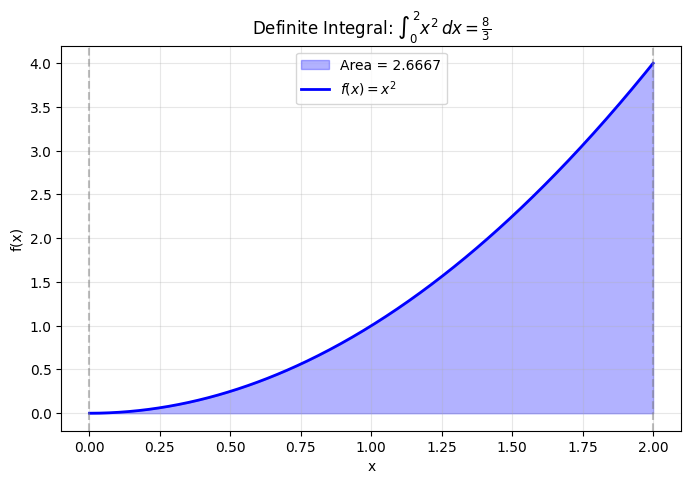

In [6]:
# Compute definite integrals using SymPy (exact values)
result1 = integrate(x**2, (x, 0, 2))
result2 = integrate(x**3, (x, 1, 3))

print("∫₀² x² dx =", result1, "=", float(result1))
print("∫₁³ x³ dx =", result2, "=", float(result2))

# Visualize area under x^2 from 0 to 2
x_vals = np.linspace(0, 2, 400)
y_vals = x_vals**2

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.fill_between(x_vals, y_vals, alpha=0.3, color='blue', label=f'Area = {float(result1):.4f}')
ax.plot(x_vals, y_vals, 'b-', linewidth=2, label=r'$f(x) = x^2$')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'Definite Integral: $\int_0^2 x^2 \, dx = \frac{8}{3}$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 6: Fundamental Theorem of Calculus

## Concept

The **Fundamental Theorem of Calculus (FTC)** connects differentiation and integration:

If $F'(x) = f(x)$, then:

$$\int_a^b f(x) \, dx = F(b) - F(a)$$

## Verification Steps

1. Find the antiderivative $F(x)$
2. Evaluate $F(b) - F(a)$
3. Compare with direct numerical integration

## AI/ML Connection

The FTC underlies **gradient descent** — we move in the direction of the negative gradient (derivative) to minimize the loss function (integral of gradients over the optimization path).

In [7]:
# Verify FTC for f(x) = x^2 on [0, 2]
a, b = 0, 2
f = x**2

# Step 1: Find antiderivative
F = integrate(f, x)
print(f"Antiderivative F(x) = {F}")

# Step 2: Evaluate F(b) - F(a)
F_b = F.subs(x, b)
F_a = F.subs(x, a)
ftc_result = F_b - F_a
print(f"F({b}) - F({a}) = {F_b} - {F_a} = {ftc_result}")

# Step 3: Direct definite integration
direct_result = integrate(f, (x, a, b))
print(f"Direct integration: {direct_result}")

print(f"\nFTC verified: {ftc_result == direct_result}")

# Numerical verification with SciPy
def f_np(x):
    return x**2

sci_result, sci_error = sci_integrate.quad(f_np, a, b)
print(f"SciPy quad result: {sci_result} (error estimate: {sci_error:.2e})")

Antiderivative F(x) = x**3/3
F(2) - F(0) = 8/3 - 0 = 8/3
Direct integration: 8/3

FTC verified: True
SciPy quad result: 2.666666666666667 (error estimate: 2.96e-14)


---

# Section 7: Area Under a Curve

## Concept

Geometrically, $\int_a^b f(x) \, dx$ represents the **signed area** between the curve $y = f(x)$ and the x-axis.

- **Positive area:** Where $f(x) > 0$ (above x-axis)
- **Negative area:** Where $f(x) < 0$ (below x-axis)

## Examples

For $f(x) = x^2$ on $[0, 2]$: all area is positive.

For $f(x) = \sin(x)$ on $[0, 2\pi]$: positive and negative areas cancel.

## AI/ML Connection

- **AUC-ROC** in classification measures the area under the ROC curve
- **Calibration curves** use area to assess model reliability

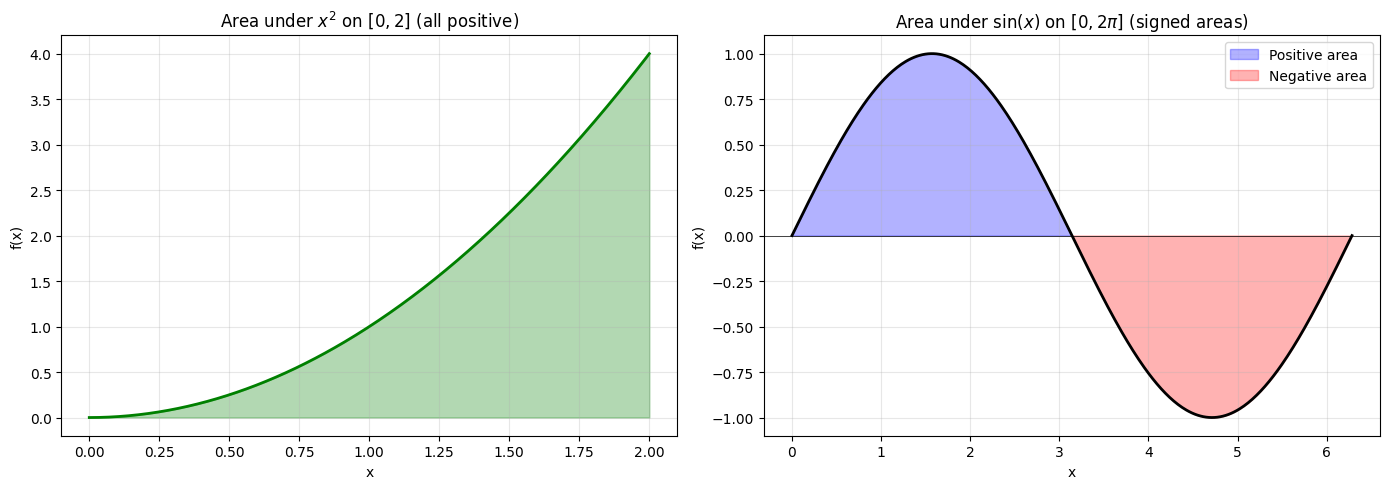

Net area (sin(x) from 0 to 2π): 0
Positive area (0 to π): 2
Negative area (π to 2π): -2


In [8]:
# Area under x^2
x_vals = np.linspace(0, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# x^2
ax1 = axes[0]
ax1.fill_between(x_vals, x_vals**2, alpha=0.3, color='green')
ax1.plot(x_vals, x_vals**2, 'g-', linewidth=2)
ax1.set_title(r'Area under $x^2$ on $[0, 2]$ (all positive)')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.grid(True, alpha=0.3)

# sin(x) on [0, 2π]
x_vals_sin = np.linspace(0, 2*np.pi, 400)
ax2 = axes[1]
ax2.fill_between(x_vals_sin, np.sin(x_vals_sin), where=(np.sin(x_vals_sin) >= 0), alpha=0.3, color='blue', label='Positive area')
ax2.fill_between(x_vals_sin, np.sin(x_vals_sin), where=(np.sin(x_vals_sin) < 0), alpha=0.3, color='red', label='Negative area')
ax2.plot(x_vals_sin, np.sin(x_vals_sin), 'k-', linewidth=2)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title(r'Area under $\sin(x)$ on $[0, 2\pi]$ (signed areas)')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute net and total area for sin(x)
net_area = integrate(sin(x), (x, 0, 2*pi))
total_positive = integrate(sin(x), (x, 0, pi))
total_negative = integrate(sin(x), (x, pi, 2*pi))
print(f"Net area (sin(x) from 0 to 2π): {net_area}")
print(f"Positive area (0 to π): {total_positive}")
print(f"Negative area (π to 2π): {total_negative}")

---

# Section 8: Riemann Sum Implementation

## Concept

Before the formal definition of integrals, we approximate area using **rectangles**. As the number of rectangles $n \rightarrow \infty$, the approximation converges to the exact integral.

## Formulas

$$\text{Left Riemann:} \quad L_n = \sum_{i=0}^{n-1} f(x_i) \Delta x$$

$$\text{Right Riemann:} \quad R_n = \sum_{i=1}^{n} f(x_i) \Delta x$$

$$\text{Midpoint:} \quad M_n = \sum_{i=0}^{n-1} f\left(\frac{x_i + x_{i+1}}{2}\right) \Delta x$$

where $\Delta x = \frac{b-a}{n}$.

## AI/ML Connection

Riemann sums are the conceptual ancestor of **numerical integration** used in:
- Approximating expectations in variational inference
- Monte Carlo sampling methods
- Discretizing continuous systems

<>:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_14216\3732296451.py:62: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.title('Riemann Sum Convergence for $\int_0^2 x^2 \, dx$')


   n     Left  Left Error    Right  Right Error  Midpoint  Midpoint Error    Exact
   4 1.750000    0.916667 3.750000     1.083333  2.625000    4.166667e-02 2.666667
   8 2.187500    0.479167 3.187500     0.520833  2.656250    1.041667e-02 2.666667
  16 2.421875    0.244792 2.921875     0.255208  2.664062    2.604167e-03 2.666667
  32 2.542969    0.123698 2.792969     0.126302  2.666016    6.510417e-04 2.666667
  64 2.604492    0.062174 2.729492     0.062826  2.666504    1.627604e-04 2.666667
 128 2.635498    0.031169 2.697998     0.031331  2.666626    4.069010e-05 2.666667
 256 2.651062    0.015605 2.682312     0.015645  2.666656    1.017253e-05 2.666667
 512 2.658859    0.007807 2.674484     0.007818  2.666664    2.543132e-06 2.666667
1024 2.662762    0.003905 2.670574     0.003908  2.666666    6.357829e-07 2.666667


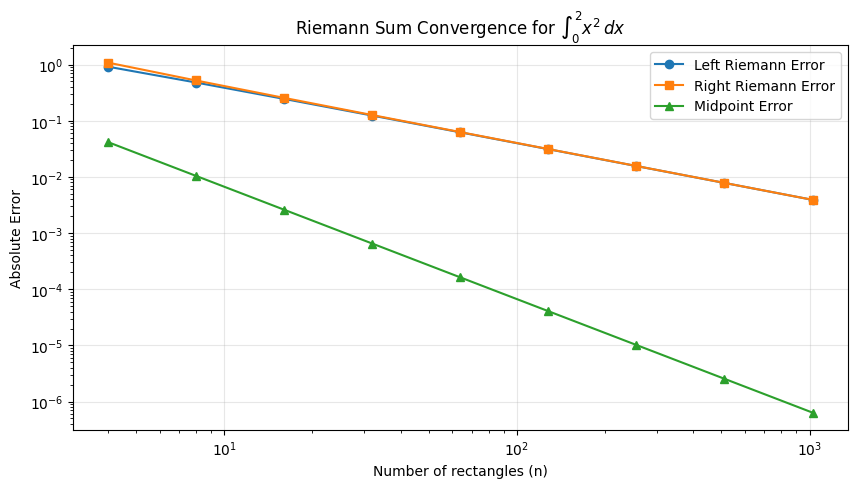

In [9]:
def left_riemann(f, a, b, n):
    """Left Riemann Sum"""
    dx = (b - a) / n
    total = 0
    for i in range(n):
        x_i = a + i * dx
        total += f(x_i) * dx
    return total

def right_riemann(f, a, b, n):
    """Right Riemann Sum"""
    dx = (b - a) / n
    total = 0
    for i in range(1, n + 1):
        x_i = a + i * dx
        total += f(x_i) * dx
    return total

def midpoint_riemann(f, a, b, n):
    """Midpoint Riemann Sum"""
    dx = (b - a) / n
    total = 0
    for i in range(n):
        x_i = a + i * dx
        x_mid = x_i + dx / 2
        total += f(x_mid) * dx
    return total

# Test with f(x) = x^2 on [0, 2]
f = lambda x: x**2
a, b = 0, 2
exact = 8/3

n_values = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
results = []

for n in n_values:
    left = left_riemann(f, a, b, n)
    right = right_riemann(f, a, b, n)
    mid = midpoint_riemann(f, a, b, n)
    results.append({
        'n': n,
        'Left': left,
        'Left Error': abs(left - exact),
        'Right': right,
        'Right Error': abs(right - exact),
        'Midpoint': mid,
        'Midpoint Error': abs(mid - exact),
        'Exact': exact
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

# Visualize convergence
plt.figure(figsize=(10, 5))
plt.loglog(n_values, df['Left Error'], 'o-', label='Left Riemann Error')
plt.loglog(n_values, df['Right Error'], 's-', label='Right Riemann Error')
plt.loglog(n_values, df['Midpoint Error'], '^-', label='Midpoint Error')
plt.xlabel('Number of rectangles (n)')
plt.ylabel('Absolute Error')
plt.title('Riemann Sum Convergence for $\int_0^2 x^2 \, dx$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# Section 9: Numerical Integration Methods

## Concept

When symbolic integration is impossible or impractical, we use **numerical methods** to approximate integrals.

## Methods

### Rectangle Rule
$$\int_a^b f(x) \, dx \approx f(a) \cdot (b - a)$$

### Midpoint Rule
$$\int_a^b f(x) \, dx \approx f\left(\frac{a+b}{2}\right) \cdot (b - a)$$

### Trapezoidal Rule
$$\int_a^b f(x) \, dx \approx \frac{b-a}{2} [f(a) + f(b)]$$

## AI/ML Connection

Numerical integration is essential for:
- Computing expectations in probabilistic models
- Evaluating intractable integrals in Bayesian inference
- Approximating gradients in continuous-time models

Exact value:      2.666667
Rectangle Rule:   0.000000  (error: 2.666667)
Midpoint Rule:    2.000000  (error: 0.666667)
Trapezoidal Rule: 4.000000  (error: 1.333333)


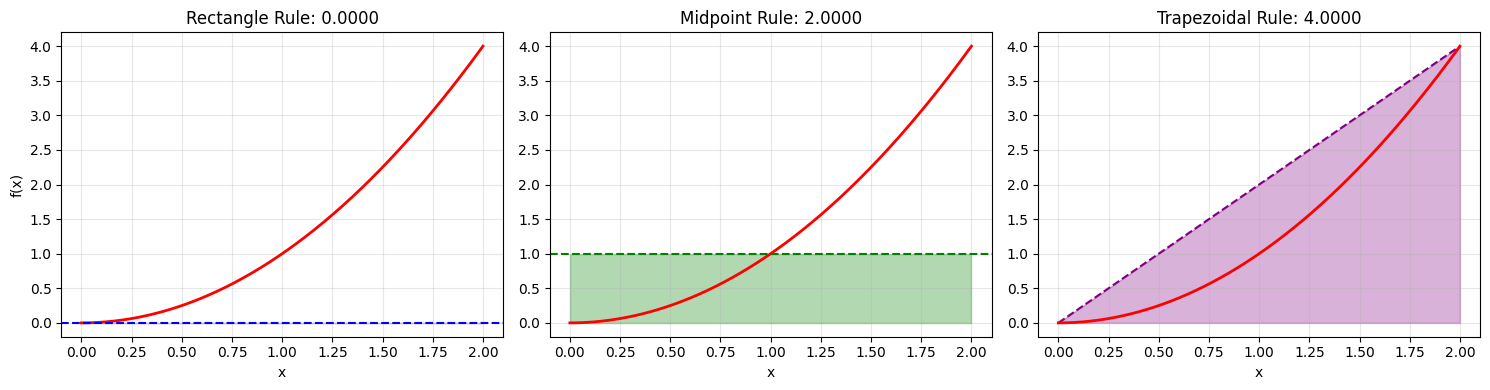

In [10]:
def rectangle_rule(f, a, b):
    """Rectangle Rule (using left endpoint)"""
    return f(a) * (b - a)

def midpoint_rule(f, a, b):
    """Midpoint Rule"""
    mid = (a + b) / 2
    return f(mid) * (b - a)

def trapezoidal_rule(f, a, b):
    """Trapezoidal Rule"""
    return (b - a) / 2 * (f(a) + f(b))

# Test with f(x) = x^2 on [0, 2]
f = lambda x: x**2
a, b = 0, 2
exact = 8/3

rect = rectangle_rule(f, a, b)
mid = midpoint_rule(f, a, b)
trap = trapezoidal_rule(f, a, b)

print(f"Exact value:      {exact:.6f}")
print(f"Rectangle Rule:   {rect:.6f}  (error: {abs(rect - exact):.6f})")
print(f"Midpoint Rule:    {mid:.6f}  (error: {abs(mid - exact):.6f})")
print(f"Trapezoidal Rule: {trap:.6f}  (error: {abs(trap - exact):.6f})")

# Visualize the methods
x_fine = np.linspace(a, b, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rectangle
ax = axes[0]
ax.fill_between([a, b], [f(a), f(a)], alpha=0.3, color='blue')
ax.plot(x_fine, f(x_fine), 'r-', linewidth=2)
ax.axhline(f(a), color='blue', linestyle='--')
ax.set_title(f'Rectangle Rule: {rect:.4f}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)

# Midpoint
ax = axes[1]
mid_y = f((a+b)/2)
ax.fill_between([a, b], [mid_y, mid_y], alpha=0.3, color='green')
ax.plot(x_fine, f(x_fine), 'r-', linewidth=2)
ax.axhline(mid_y, color='green', linestyle='--')
ax.set_title(f'Midpoint Rule: {mid:.4f}')
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)

# Trapezoidal
ax = axes[2]
ax.fill_between([a, b], [f(a), f(b)], alpha=0.3, color='purple')
ax.plot([a, b], [f(a), f(b)], 'purple', linestyle='--')
ax.plot(x_fine, f(x_fine), 'r-', linewidth=2)
ax.set_title(f'Trapezoidal Rule: {trap:.4f}')
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Section 10: Simpson's Rule

## Concept

**Simpson's Rule** approximates the integrand by a **parabola** (quadratic polynomial) rather than a straight line, yielding much higher accuracy.

## Formula

$$\int_a^b f(x) \, dx \approx \frac{b-a}{6} \left[ f(a) + 4f\left(\frac{a+b}{2}\right) + f(b) \right]$$

## Error Analysis

- Simpson's Rule is exact for polynomials up to degree 3
- Error is proportional to $(b-a)^5$ (much smaller than trapezoidal!)

## AI/ML Connection

High-accuracy numerical integration is used in:
- **Normalizing flows** (computing change of variables)
- **Diffusion models** (solving SDEs numerically)
- **Physics-informed neural networks** (enforcing conservation laws)

In [11]:
def simpsons_rule(f, a, b):
    """Simpson's Rule for single interval"""
    mid = (a + b) / 2
    return (b - a) / 6 * (f(a) + 4*f(mid) + f(b))

# Compare all methods on f(x) = x^2 on [0, 2]
f = lambda x: x**2
a, b = 0, 2
exact = 8/3

rect = rectangle_rule(f, a, b)
mid = midpoint_rule(f, a, b)
trap = trapezoidal_rule(f, a, b)
simp = simpsons_rule(f, a, b)

comparison_data = {
    'Method': ['Rectangle', 'Midpoint', 'Trapezoidal', "Simpson's", 'Exact'],
    'Result': [rect, mid, trap, simp, exact],
    'Error': [abs(rect - exact), abs(mid - exact), abs(trap - exact), abs(simp - exact), 0]
}

df_compare = pd.DataFrame(comparison_data)
print(df_compare.to_string(index=False))

# Test on a more complex function: f(x) = e^(-x^2) on [0, 1]
# This is related to the error function (erf), which has no closed form
f2 = lambda x: np.exp(-x**2)
a2, b2 = 0, 1
exact2, _ = sci_integrate.quad(f2, a2, b2)

rect2 = rectangle_rule(f2, a2, b2)
mid2 = midpoint_rule(f2, a2, b2)
trap2 = trapezoidal_rule(f2, a2, b2)
simp2 = simpsons_rule(f2, a2, b2)

print(f"\n--- e^(-x^2) on [0, 1] ---")
print(f"Exact (SciPy):    {exact2:.8f}")
print(f"Rectangle:        {rect2:.8f}  error: {abs(rect2 - exact2):.2e}")
print(f"Midpoint:         {mid2:.8f}  error: {abs(mid2 - exact2):.2e}")
print(f"Trapezoidal:      {trap2:.8f}  error: {abs(trap2 - exact2):.2e}")
print(f"Simpson's:        {simp2:.8f}  error: {abs(simp2 - exact2):.2e}")

     Method   Result    Error
  Rectangle 0.000000 2.666667
   Midpoint 2.000000 0.666667
Trapezoidal 4.000000 1.333333
  Simpson's 2.666667 0.000000
      Exact 2.666667 0.000000

--- e^(-x^2) on [0, 1] ---
Exact (SciPy):    0.74682413
Rectangle:        1.00000000  error: 2.53e-01
Midpoint:         0.77880078  error: 3.20e-02
Trapezoidal:      0.68393972  error: 6.29e-02
Simpson's:        0.74718043  error: 3.56e-04


---

# Section 11: SciPy Integration

## Concept

`scipy.integrate.quad()` is a powerful adaptive numerical integration routine that automatically handles:
- Infinite limits
- Singularities
- High-precision requirements

## Examples

$$\int_{-\infty}^{\infty} e^{-x^2} \, dx = \sqrt{\pi}$$

$$\int_0^{\pi} \sin(x) \, dx = 2$$

## AI/ML Connection

SciPy integration is used in:
- Computing partition functions in probabilistic models
- Evaluating evidence in Bayesian model comparison
- Normalizing probability distributions

In [13]:
# Example 1: Gaussian integral
result1, err1 = sci_integrate.quad(lambda x: np.exp(-x**2), -np.inf, np.inf)
print(f"∫_{'{'}'-∞'{'}'}^{'{'}'∞'{'}'} e^(-x²) dx = {result1:.10f}")
print(f"Exact value (sqrt(π)) = {np.sqrt(np.pi):.10f}")
print(f"Error estimate: {err1:.2e}")

# Example 2: sin(x) from 0 to π
result2, err2 = sci_integrate.quad(lambda x: np.sin(x), 0, np.pi)
print(f"\n∫_0^π sin(x) dx = {result2:.10f}")

# Example 3: A more complex function (used in ML: sigmoid-like)
result3, err3 = sci_integrate.quad(lambda x: 1 / (1 + x**2), -np.inf, np.inf)
print(f"\n∫_{'{'}'-∞'{'}'}^{'{'}'∞'{'}'} 1/(1+x²) dx = {result3:.10f}")
print(f"Exact value (π) = {np.pi:.10f}")

# Example 4: Integral with parameters (Beta function related)
alpha, beta = 2, 3
result4, err4 = sci_integrate.quad(lambda t: t**(alpha-1) * (1-t)**(beta-1), 0, 1)
print(f"\nBeta({alpha}, {beta}) = {result4:.10f}")
print(f"Exact (Γ(α)Γ(β)/Γ(α+β)) = {np.gamma(alpha)*np.gamma(beta)/np.gamma(alpha+beta):.10f}")

∫_{'-∞'}^{'∞'} e^(-x²) dx = 1.7724538509
Exact value (sqrt(π)) = 1.7724538509
Error estimate: 1.42e-08

∫_0^π sin(x) dx = 2.0000000000

∫_{'-∞'}^{'∞'} 1/(1+x²) dx = 3.1415926536
Exact value (π) = 3.1415926536

Beta(2, 3) = 0.0833333333


AttributeError: module 'numpy' has no attribute 'gamma'

---

# Section 12: Improper Integrals

## Concept

An **improper integral** has either:
- Infinite limits of integration
- An integrand that becomes infinite within the interval

## Example

$$\int_1^{\infty} \frac{1}{x^2} \, dx = \lim_{b \to \infty} \left[ -\frac{1}{x} \right]_1^b = 0 - (-1) = 1$$

This integral **converges** to 1.

## Convergence Test

Compare with $\int_1^{\infty} \frac{1}{x} \, dx$ which **diverges** (harmonic series in continuous form).

## AI/ML Connection

Improper integrals appear in:
- **Normalization of heavy-tailed distributions** (Cauchy, Pareto)
- **KL divergence** computations
- **Expected values** with unbounded support

∫_1^∞ 1/x² dx = 1
∫_1^∞ 1/x dx = oo

Numerical verification: 1.0000000000 (error: 1.11e-14)


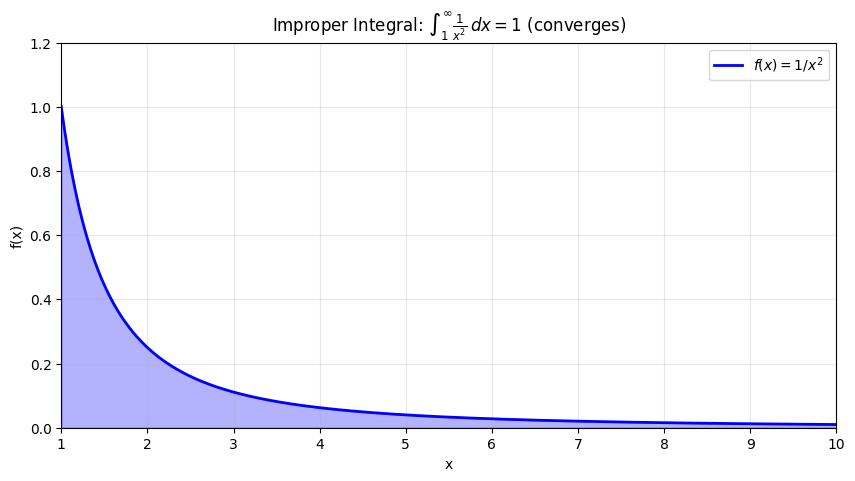

In [14]:
# Symbolic improper integral with SymPy
x = symbols('x')

# ∫_1^∞ 1/x^2 dx
result1 = integrate(1/x**2, (x, 1, oo))
print(f"∫_1^∞ 1/x² dx = {result1}")

# ∫_1^∞ 1/x dx (should diverge)
result2 = integrate(1/x, (x, 1, oo))
print(f"∫_1^∞ 1/x dx = {result2}")

# Numerical verification with SciPy
result_num, err = sci_integrate.quad(lambda x: 1/x**2, 1, np.inf)
print(f"\nNumerical verification: {result_num:.10f} (error: {err:.2e})")

# Visualize convergence
x_vals = np.linspace(1, 10, 400)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.fill_between(x_vals, 1/x_vals**2, alpha=0.3, color='blue')
ax.plot(x_vals, 1/x_vals**2, 'b-', linewidth=2, label=r'$f(x) = 1/x^2$')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'Improper Integral: $\int_1^\infty \frac{1}{x^2} \, dx = 1$ (converges)')
ax.set_xlim(1, 10)
ax.set_ylim(0, 1.2)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 13: Double Integrals

## Concept

A **double integral** $\iint_R f(x,y) \, dA$ computes the **volume** under a surface $z = f(x,y)$ over a region $R$ in the $xy$-plane.

## Example

For $f(x,y) = x + y$ over the rectangle $[0, 1] \times [0, 1]$:

$$\iint_R (x + y) \, dA = \int_0^1 \int_0^1 (x + y) \, dx \, dy = 1$$

## AI/ML Connection

Double integrals appear in:
- **Joint probability distributions** (computing marginal probabilities)
- **Covariance matrices** (multivariate statistics)
- **2D convolution** in image processing (CNNs)

Inner integral (∫_0^1 (x+y) dx): y + 1/2
Outer integral (∫_0^1 [y + 1/2] dy): 1

Double integral result: 1


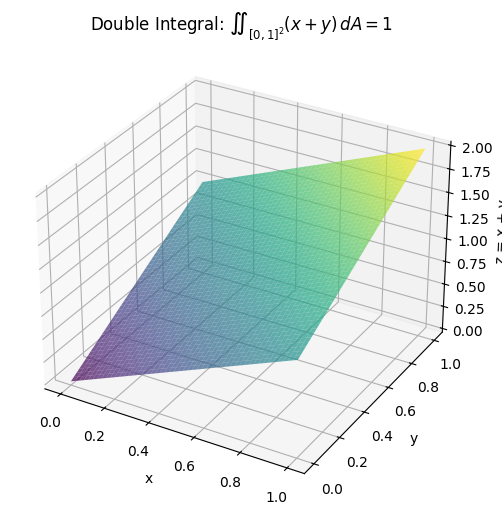

In [15]:
# Double integral using SymPy
x, y = symbols('x y')

# f(x,y) = x + y over [0,1] x [0,1]
f = x + y

# Integrate with respect to x first, then y
inner = integrate(f, (x, 0, 1))
print(f"Inner integral (∫_0^1 (x+y) dx): {inner}")

outer = integrate(inner, (y, 0, 1))
print(f"Outer integral (∫_0^1 [{inner}] dy): {outer}")

# One-liner
double_result = integrate(f, (x, 0, 1), (y, 0, 1))
print(f"\nDouble integral result: {double_result}")

# Visualize the surface
from mpl_toolkits.mplot3d import Axes3D
X = np.linspace(0, 1, 50)
Y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(X, Y)
Z = X + Y

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.7, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z = x + y')
ax.set_title(r'Double Integral: $\iint_{[0,1]^2} (x+y) \, dA = 1$')
plt.show()

---

# Section 14: Triple Integrals

## Concept

A **triple integral** $\iiint_V f(x,y,z) \, dV$ computes accumulated quantity in 3D space.

## Example

For $f(x,y,z) = x + y + z$ over the unit cube $[0,1]^3$:

$$\iiint_V (x + y + z) \, dV = \int_0^1 \int_0^1 \int_0^1 (x + y + z) \, dx \, dy \, dz = \frac{3}{2}$$

## AI/ML Connection

Triple integrals appear in:
- **3D convolution** in volumetric CNNs (medical imaging)
- **3D probability distributions** (spatial modeling)
- **Physics simulations** for AI (fluid dynamics, particle systems)

In [16]:
# Triple integral using SymPy
x, y, z = symbols('x y z')

f = x + y + z

# Integrate over unit cube [0,1]^3
triple_result = integrate(f, (x, 0, 1), (y, 0, 1), (z, 0, 1))
print(f"Triple integral of (x+y+z) over [0,1]^3: {triple_result}")
print(f"Numerical value: {float(triple_result)}")

# Step by step
step1 = integrate(f, (x, 0, 1))
print(f"\nAfter x-integration: {step1}")
step2 = integrate(step1, (y, 0, 1))
print(f"After y-integration: {step2}")
step3 = integrate(step2, (z, 0, 1))
print(f"After z-integration: {step3}")

Triple integral of (x+y+z) over [0,1]^3: 3/2
Numerical value: 1.5

After x-integration: y + z + 1/2
After y-integration: z + 1
After z-integration: 3/2


---

# Section 15: Integration of Trigonometric Functions

## Concept

Trigonometric functions are fundamental in:
- Periodic phenomena (time series, signals)
- Fourier analysis (frequency decomposition)
- Wave-based models

## Key Integrals

$$\int \sin(x) \, dx = -\cos(x) + C$$

$$\int \cos(x) \, dx = \sin(x) + C$$

$$\int \tan(x) \, dx = -\ln|\cos(x)| + C$$

## AI/ML Connection

Trigonometric integrals are central to:
- **Fourier Neural Operators** (solving PDEs with AI)
- **Positional encodings** in Transformers
- **Signal processing** in audio/speech models

∫ sin(x) dx = -cos(x) + C
∫ cos(x) dx = sin(x) + C
∫ tan(x) dx = -log(cos(x)) + C
∫ sec(x)^2 dx = sin(x)/cos(x) + C


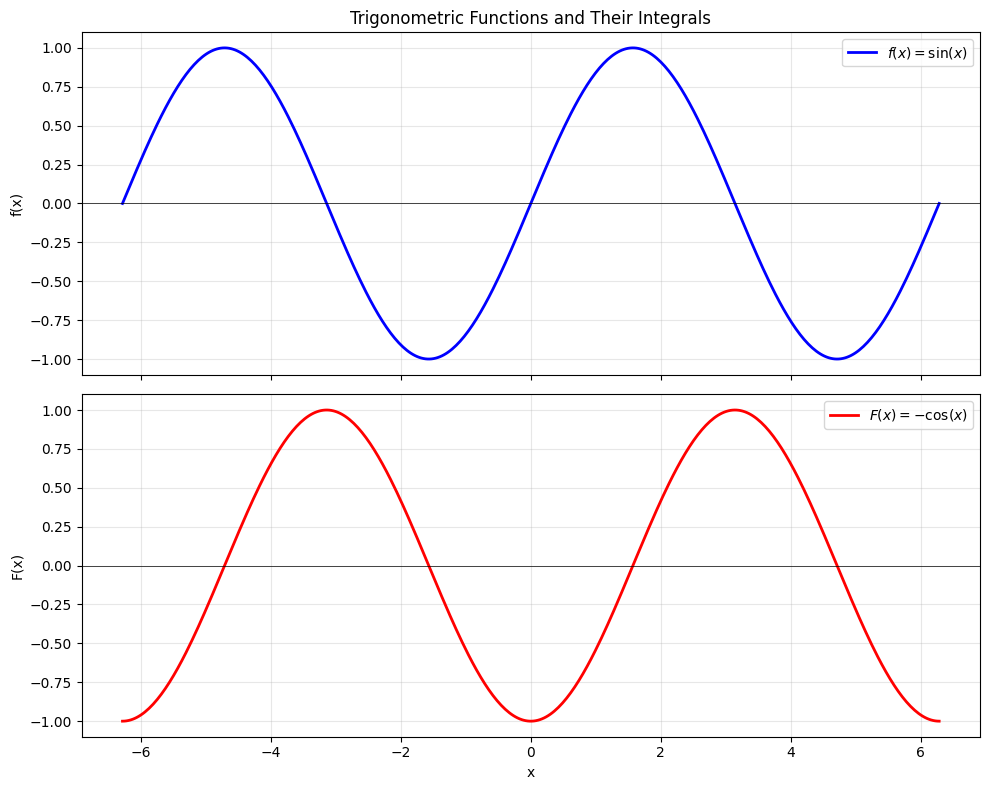

In [17]:
x = symbols('x')

# Trigonometric integrals
trig_integrals = {
    'sin(x)': integrate(sin(x), x),
    'cos(x)': integrate(cos(x), x),
    'tan(x)': integrate(sp.tan(x), x),
    'sec(x)^2': integrate(1/sp.cos(x)**2, x),
}

for func, result in trig_integrals.items():
    print(f"∫ {func} dx = {result} + C")

# Visualize sin(x) and its integral -cos(x)
x_vals = np.linspace(-2*np.pi, 2*np.pi, 400)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x_vals, np.sin(x_vals), 'b-', linewidth=2, label=r'$f(x) = \sin(x)$')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('f(x)')
axes[0].set_title('Trigonometric Functions and Their Integrals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, -np.cos(x_vals), 'r-', linewidth=2, label=r'$F(x) = -\cos(x)$')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Section 16: Integration of Exponential Functions

## Concept

The exponential function $e^x$ is unique because it is its own derivative and integral.

## Key Integrals

$$\int e^x \, dx = e^x + C$$

$$\int a^x \, dx = \frac{a^x}{\ln(a)} + C$$

## AI/ML Connection

Exponential integrals are crucial for:
- **Softmax normalization** (Boltzmann distributions)
- **Entropy calculations** in information theory
- **Exponential family distributions** (Gaussian, Poisson, Bernoulli)
- **Learning rate schedules** (exponential decay)

∫ e^x dx = exp(x) + C
∫ 2^x dx = 2**x/log(2) + C
∫ e^(-x) dx = -exp(-x) + C

∫_0^∞ e^(-x) dx = 1
This is the normalization constant for the exponential distribution!


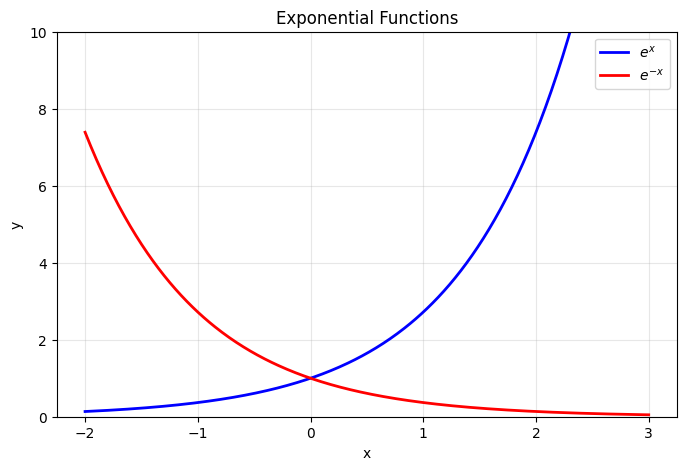

In [18]:
x = symbols('x')

# Exponential integrals
exp_integrals = {
    'e^x': integrate(exp(x), x),
    '2^x': integrate(2**x, x),
    'e^(-x)': integrate(exp(-x), x),
}

for func, result in exp_integrals.items():
    print(f"∫ {func} dx = {result} + C")

# Definite integral of e^(-x) from 0 to ∞ (used in exponential distributions)
result = integrate(exp(-x), (x, 0, oo))
print(f"\n∫_0^∞ e^(-x) dx = {result}")

# This is the normalization of exponential distribution with λ=1
print("This is the normalization constant for the exponential distribution!")

# Visualize
x_vals = np.linspace(-2, 3, 400)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(x_vals, np.exp(x_vals), 'b-', linewidth=2, label=r'$e^x$')
ax.plot(x_vals, np.exp(-x_vals), 'r-', linewidth=2, label=r'$e^{-x}$')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Exponential Functions')
ax.set_ylim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 17: Integration of Logarithmic Functions

## Concept

The integral $\int \frac{1}{x} \, dx = \ln|x| + C$ is a special case that doesn't fit the power rule (which would give division by zero for $n = -1$).

## Key Integrals

$$\int \frac{1}{x} \, dx = \ln|x| + C$$

$$\int \ln(x) \, dx = x\ln(x) - x + C$$

## Why the Power Rule Fails

The power rule $\int x^n \, dx = \frac{x^{n+1}}{n+1} + C$ requires $n \neq -1$. At $n = -1$, the denominator becomes zero, so we need a different formula.

## AI/ML Connection

Logarithmic integrals appear in:
- **Cross-entropy loss** (logarithmic expectations)
- **KL divergence** (integrals of log-ratios)
- **Information theory** (entropy integrals)

∫ 1/x dx = log(x) + C
∫ ln(x) dx = x*log(x) - x + C

Verification: d/dx[log(x)] = 1/x
Verification: d/dx[x*log(x) - x] = log(x)

∫_1^e 1/x dx = 1


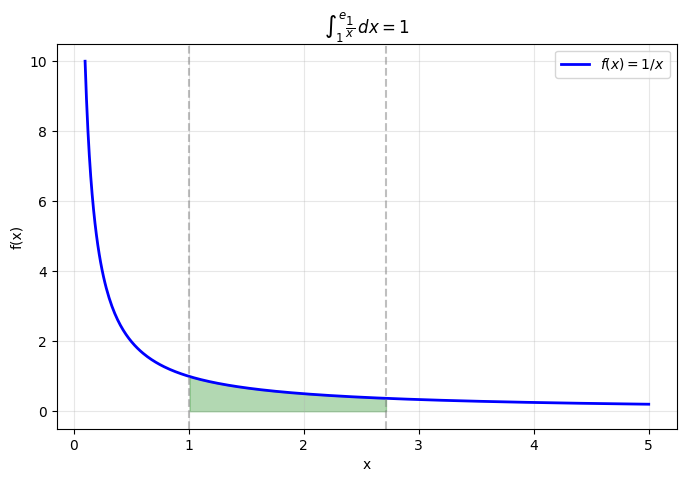

In [19]:
x = symbols('x')

# Logarithmic integrals
log_result1 = integrate(1/x, x)
log_result2 = integrate(log(x), x)

print(f"∫ 1/x dx = {log_result1} + C")
print(f"∫ ln(x) dx = {log_result2} + C")

# Verify by differentiating
print(f"\nVerification: d/dx[{log_result1}] = {diff(log_result1, x)}")
print(f"Verification: d/dx[{log_result2}] = {diff(log_result2, x)}")

# Definite integral: ∫_1^e 1/x dx = 1
result_def = integrate(1/x, (x, 1, sp.E))
print(f"\n∫_1^e 1/x dx = {result_def}")

# Visualize
x_vals = np.linspace(0.1, 5, 400)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(x_vals, 1/x_vals, 'b-', linewidth=2, label=r'$f(x) = 1/x$')
ax.fill_between(x_vals[(x_vals >= 1) & (x_vals <= np.e)], 
                 1/x_vals[(x_vals >= 1) & (x_vals <= np.e)], 
                 alpha=0.3, color='green')
ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
ax.axvline(np.e, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'$\int_1^e \frac{1}{x} \, dx = 1$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 18: Probability Density Functions

## Concept

A **Probability Density Function (PDF)** $p(x)$ must satisfy:

$$\int_{-\infty}^{\infty} p(x) \, dx = 1$$

This is called **normalization** — the total probability mass must equal 1.

## Normal Distribution PDF

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

## AI/ML Connection

PDFs are fundamental to:
- **Maximum Likelihood Estimation** (fitting models to data)
- **Bayesian inference** (posterior distributions)
- **Generative models** (learning data distributions)
- **Anomaly detection** (probability thresholding)

∫_{'-∞'}^{'∞'} N(x; μ=0, σ=1) dx = 1.0000000000
Error estimate: 1.02e-08


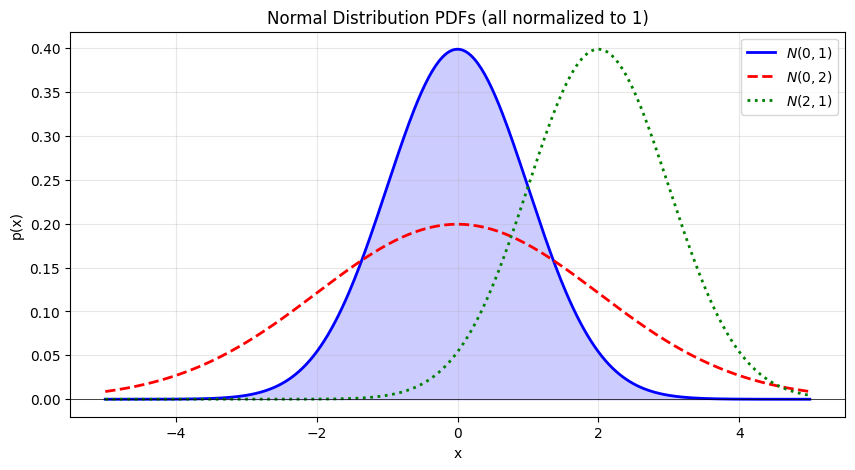


P(-1 < X < 1) = 0.682689 (~68%)
P(-2 < X < 2) = 0.954500 (~95%)
P(-3 < X < 3) = 0.997300 (~99.7%)


In [20]:
# Define Normal Distribution PDF
def normal_pdf(x, mu=0, sigma=1):
    """Standard Normal PDF"""
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Verify normalization: ∫_{-∞}^{∞} p(x) dx = 1
result, error = sci_integrate.quad(normal_pdf, -np.inf, np.inf, args=(0, 1))
print(f"∫_{'{'}'-∞'{'}'}^{'{'}'∞'{'}'} N(x; μ=0, σ=1) dx = {result:.10f}")
print(f"Error estimate: {error:.2e}")

# Visualize the PDF
x_vals = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x_vals, normal_pdf(x_vals, 0, 1), 'b-', linewidth=2, label=r'$N(0, 1)$')
ax.plot(x_vals, normal_pdf(x_vals, 0, 2), 'r--', linewidth=2, label=r'$N(0, 2)$')
ax.plot(x_vals, normal_pdf(x_vals, 2, 1), 'g:', linewidth=2, label=r'$N(2, 1)$')
ax.fill_between(x_vals, normal_pdf(x_vals, 0, 1), alpha=0.2, color='blue')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Normal Distribution PDFs (all normalized to 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Compute probability P(-1 < X < 1) for N(0,1)
prob_1sigma, _ = sci_integrate.quad(normal_pdf, -1, 1, args=(0, 1))
prob_2sigma, _ = sci_integrate.quad(normal_pdf, -2, 2, args=(0, 1))
prob_3sigma, _ = sci_integrate.quad(normal_pdf, -3, 3, args=(0, 1))

print(f"\nP(-1 < X < 1) = {prob_1sigma:.6f} (~68%)")
print(f"P(-2 < X < 2) = {prob_2sigma:.6f} (~95%)")
print(f"P(-3 < X < 3) = {prob_3sigma:.6f} (~99.7%)")

---

# Section 19: Expected Value Calculation

## Concept

The **expected value** (mean) of a continuous random variable is:

$$E[X] = \int_{-\infty}^{\infty} x \, p(x) \, dx$$

## Uniform Distribution

For $X \sim U(a, b)$:

$$E[X] = \int_a^b x \, \frac{1}{b-a} \, dx = \frac{a+b}{2}$$

## Gaussian Distribution

For $X \sim N(\mu, \sigma^2)$:

$$E[X] = \int_{-\infty}^{\infty} x \, \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} \, dx = \mu$$

## AI/ML Connection

Expected values are used in:
- **Policy gradient methods** (expected reward)
- **Variational inference** (ELBO optimization)
- **Model averaging** (expected prediction)
- **Risk assessment** (expected loss)

In [21]:
# Expected value of Uniform Distribution U(0, 10)
a, b = 0, 10
uniform_pdf = lambda x: 1/(b-a) if a <= x <= b else 0

# Numerical integration
E_uniform, _ = sci_integrate.quad(lambda x: x * uniform_pdf(x), a, b)
print(f"E[X] for U(0, 10) = {E_uniform:.4f}")
print(f"Theoretical: (a+b)/2 = {(a+b)/2:.4f}")

# Expected value of Normal Distribution N(5, 4)
mu, sigma = 5, 2

def normal_pdf_param(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

E_normal, _ = sci_integrate.quad(lambda x: x * normal_pdf_param(x, mu, sigma), -np.inf, np.inf)
print(f"\nE[X] for N(5, 4) = {E_normal:.6f}")
print(f"Theoretical: μ = {mu}")

# Second moment: E[X^2] = Var(X) + E[X]^2
E_x2, _ = sci_integrate.quad(lambda x: x**2 * normal_pdf_param(x, mu, sigma), -np.inf, np.inf)
variance = E_x2 - E_normal**2
print(f"\nE[X²] = {E_x2:.4f}")
print(f"Var(X) = E[X²] - E[X]² = {variance:.4f}")
print(f"Theoretical σ² = {sigma**2}")

E[X] for U(0, 10) = 5.0000
Theoretical: (a+b)/2 = 5.0000

E[X] for N(5, 4) = 5.000000
Theoretical: μ = 5

E[X²] = 29.0000
Var(X) = E[X²] - E[X]² = 4.0000
Theoretical σ² = 4


---

# Section 20: Gaussian Distribution Example

## Concept

The **Gaussian (Normal) distribution** is the most important distribution in statistics and ML. We compute its properties using integration.

## Properties to Compute

1. **Mean:** $E[X] = \mu$
2. **Variance:** $E[(X - \mu)^2] = \sigma^2$
3. **Probability intervals:** $P(a < X < b)$

## AI/ML Connection

Gaussians are used in:
- **Gaussian Mixture Models** (clustering)
- **Kalman Filters** (state estimation)
- **Diffusion models** (noise schedules)
- **Bayesian neural networks** (weight priors)

In [22]:
mu, sigma = 0, 1

# Compute mean, variance, and probability intervals using integration
E_X, _ = sci_integrate.quad(lambda x: x * normal_pdf_param(x, mu, sigma), -np.inf, np.inf)
E_X2, _ = sci_integrate.quad(lambda x: x**2 * normal_pdf_param(x, mu, sigma), -np, np.inf)
variance = E_X2 - E_X**2

print(f"Gaussian N(0, 1) Properties:")
print(f"  Mean (E[X]):      {E_X:.6f}")
print(f"  Variance:         {variance:.6f}")
print(f"  Std Dev:          {np.sqrt(variance):.6f}")

# Probability intervals
intervals = [(-1, 1), (-2, 2), (-3, 3), (0, 1), (-1.96, 1.96)]
print(f"\nProbability Intervals:")
for a, b in intervals:
    prob, _ = sci_integrate.quad(lambda x: normal_pdf_param(x, mu, sigma), a, b)
    print(f"  P({a:+.2f} < X < {b:+.2f}) = {prob:.6f}")

# Visualize with shaded intervals
x_vals = np.linspace(-4, 4, 400)
y_vals = normal_pdf_param(x_vals, mu, sigma)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x_vals, y_vals, 'b-', linewidth=2)
ax.fill_between(x_vals, y_vals, where=((x_vals >= -1) & (x_vals <= 1)), alpha=0.3, color='green', label='±1σ (68%)')
ax.fill_between(x_vals, y_vals, where=((x_vals >= -2) & (x_vals <= -1)) | ((x_vals >= 1) & (x_vals <= 2)), alpha=0.3, color='yellow', label='1σ to 2σ (27%)')
ax.fill_between(x_vals, y_vals, where=((x_vals >= -3) & (x_vals <= -2)) | ((x_vals >= 2) & (x_vals <= 3)), alpha=0.3, color='red', label='2σ to 3σ (4%)')
ax.axvline(mu, color='black', linestyle='--', label=f'Mean = {mu}')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Gaussian Distribution with Probability Intervals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

TypeError: bad operand type for unary -: 'module'

---

# Section 21: Bayesian Probability Example

## Concept

In **Bayesian inference**, we update beliefs using Bayes' theorem:

$$P(\theta | D) = \frac{P(D | \theta) \, P(\theta)}{P(D)}$$

The **evidence** $P(D)$ requires integration:

$$P(D) = \int P(D | \theta) \, P(\theta) \, d\theta$$

## Example: Coin Flip

Suppose we flip a coin 10 times and observe 7 heads. We want to infer the bias $\theta$.

- Likelihood: $P(D | \theta) = \binom{10}{7} \theta^7 (1-\theta)^3$
- Prior: $P(\theta) = 1$ (uniform on [0,1])
- Posterior: $P(\theta | D) = \frac{\theta^7 (1-\theta)^3}{\int_0^1 \theta^7 (1-\theta)^3 \, d\theta}$

## AI/ML Connection

Bayesian integration is central to:
- **Bayesian neural networks** (uncertainty quantification)
- **Gaussian processes** (kernel methods)
- **Variational inference** (approximate posterior computation)
- **MCMC methods** (sampling from posteriors)

Evidence (normalizing constant): 1/1320 = 0.000758

Posterior PDF: P(θ|D) = 1320*theta**7*(1 - theta)**3
Normalization check: ∫_0^1 P(θ|D) dθ = 1

Derivative of posterior: theta**6*(9240 - 13200*theta)*(theta - 1)**2
MAP estimate: θ = 0.7 (matches MLE with 7/10 heads)


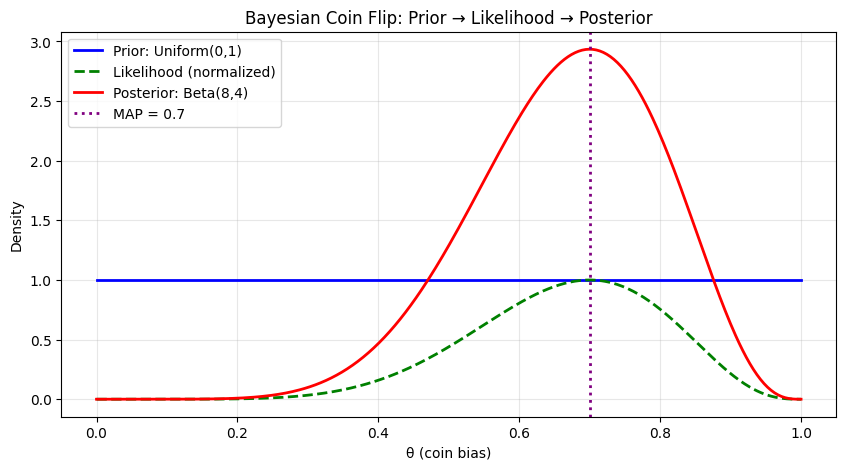

In [23]:
# Bayesian Coin Flip Example
# Prior: Uniform(0, 1)
# Likelihood: Binomial(10, 7) -> θ^7 * (1-θ)^3
# Evidence: ∫_0^1 θ^7 * (1-θ)^3 dθ

theta = symbols('theta', positive=True)

# Unnormalized posterior
unnormalized = theta**7 * (1 - theta)**3

# Compute evidence (normalizing constant)
evidence = integrate(unnormalized, (theta, 0, 1))
print(f"Evidence (normalizing constant): {evidence} = {float(evidence):.6f}")

# Posterior PDF
posterior = unnormalized / evidence
print(f"\nPosterior PDF: P(θ|D) = {posterior}")

# Verify normalization
normalization_check = integrate(posterior, (theta, 0, 1))
print(f"Normalization check: ∫_0^1 P(θ|D) dθ = {normalization_check}")

# MAP estimate (mode of posterior)
posterior_derivative = diff(posterior, theta)
print(f"\nDerivative of posterior: {simplify(posterior_derivative)}")

# For Beta(8, 4), mode = (α-1)/(α+β-2) = 7/10 = 0.7
map_estimate = 7/10
print(f"MAP estimate: θ = {map_estimate} (matches MLE with 7/10 heads)")

# Visualize prior, likelihood, and posterior
theta_vals = np.linspace(0, 1, 400)

# Convert sympy expressions to numpy functions
from sympy import lambdify
posterior_func = lambdify(theta, posterior, 'numpy')
likelihood_vals = theta_vals**7 * (1 - theta_vals)**3

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(theta_vals, np.ones_like(theta_vals), 'b-', linewidth=2, label='Prior: Uniform(0,1)')
ax.plot(theta_vals, likelihood_vals / np.max(likelihood_vals), 'g--', linewidth=2, label='Likelihood (normalized)')
ax.plot(theta_vals, posterior_func(theta_vals), 'r-', linewidth=2, label='Posterior: Beta(8,4)')
ax.axvline(0.7, color='purple', linestyle=':', linewidth=2, label='MAP = 0.7')
ax.set_xlabel('θ (coin bias)')
ax.set_ylabel('Density')
ax.set_title('Bayesian Coin Flip: Prior → Likelihood → Posterior')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 22: Reinforcement Learning Example

## Concept

In **Reinforcement Learning**, the goal is to maximize **expected cumulative reward**:

$$E[R] = \int R(\tau) \, P(\tau | \pi) \, d\tau$$

where $\tau$ is a trajectory and $\pi$ is the policy.

## Simplified Example

Consider a policy with two possible actions:
- Action A: reward = 10 with probability 0.6
- Action B: reward = 5 with probability 0.4

$$E[R] = 10 \times 0.6 + 5 \times 0.4 = 8$$

## AI/ML Connection

Expected reward integration is fundamental to:
- **Policy gradient methods** (REINFORCE, Actor-Critic)
- **Q-learning** (expected future rewards)
- **Monte Carlo tree search** (expected value of actions)
- **Multi-armed bandits** (exploration vs exploitation)

Expected Reward:
  Path A (N(10, 4)): E[R] = 10.0000
  Path B (N(8, 1)):  E[R] = 8.0000

Probability of reward > 9:
  Path A: P(R > 9) = 0.6915
  Path B: P(R > 9) = 0.1587

Probability of reward < 5 (risk):
  Path A: P(R < 5) = 0.0062
  Path B: P(R < 5) = 0.0013


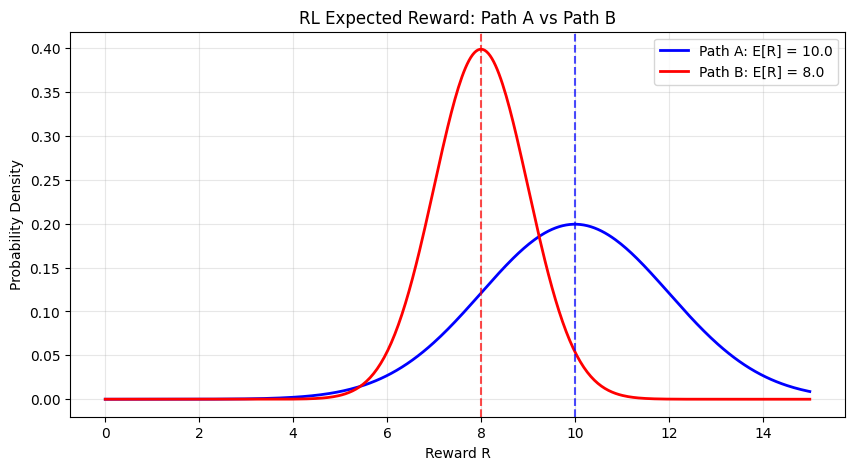

In [24]:
# Reinforcement Learning: Expected Reward

# Scenario: A robot can choose paths with different reward distributions
# Path A: Reward ~ N(10, 4)  (high reward, high variance)
# Path B: Reward ~ N(8, 1)   (lower reward, low variance)

# Define reward distributions
def reward_pdf_A(r):
    """PDF of reward for Path A: N(10, 4)"""
    mu, sigma = 10, 2
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((r - mu) / sigma)**2)

def reward_pdf_B(r):
    """PDF of reward for Path B: N(8, 1)"""
    mu, sigma = 8, 1
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((r - mu) / sigma)**2)

# Expected reward for each path
E_A, _ = sci_integrate.quad(lambda r: r * reward_pdf_A(r), -np.inf, np.inf)
E_B, _ = sci_integrate.quad(lambda r: r * reward_pdf_B(r), -np.inf, np.inf)

print(f"Expected Reward:")
print(f"  Path A (N(10, 4)): E[R] = {E_A:.4f}")
print(f"  Path B (N(8, 1)):  E[R] = {E_B:.4f}")

# Probability of reward > 9 for each path
P_A_gt_9, _ = sci_integrate.quad(reward_pdf_A, 9, np.inf)
P_B_gt_9, _ = sci_integrate.quad(reward_pdf_B, 9, np.inf)

print(f"\nProbability of reward > 9:")
print(f"  Path A: P(R > 9) = {P_A_gt_9:.4f}")
print(f"  Path B: P(R > 9) = {P_B_gt_9:.4f}")

# Risk analysis: P(R < 5) for each path
P_A_lt_5, _ = sci_integrate.quad(reward_pdf_A, -np.inf, 5)
P_B_lt_5, _ = sci_integrate.quad(reward_pdf_B, -np.inf, 5)

print(f"\nProbability of reward < 5 (risk):")
print(f"  Path A: P(R < 5) = {P_A_lt_5:.4f}")
print(f"  Path B: P(R < 5) = {P_B_lt_5:.4f}")

# Visualize
r_vals = np.linspace(0, 15, 400)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(r_vals, reward_pdf_A(r_vals), 'b-', linewidth=2, label=f'Path A: E[R] = {E_A:.1f}')
ax.plot(r_vals, reward_pdf_B(r_vals), 'r-', linewidth=2, label=f'Path B: E[R] = {E_B:.1f}')
ax.axvline(E_A, color='blue', linestyle='--', alpha=0.7)
ax.axvline(E_B, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Reward R')
ax.set_ylabel('Probability Density')
ax.set_title('RL Expected Reward: Path A vs Path B')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 23: Neural ODE Example

## Concept

**Neural Ordinary Differential Equations (Neural ODEs)** model continuous-time dynamics:

$$\frac{dh(t)}{dt} = f(h(t), t, \theta)$$

The solution is obtained by **integration**:

$$h(t_1) = h(t_0) + \int_{t_0}^{t_1} f(h(t), t, \theta) \, dt$$

## Simple Example

Consider a linear dynamics: $\frac{dh}{dt} = -0.5h$

Solution: $h(t) = h(0) \cdot e^{-0.5t}$

## AI/ML Connection

Neural ODEs are used in:
- **Continuous Normalizing Flows** (density estimation)
- **Time-series forecasting** (irregularly sampled data)
- **Physics-informed learning** (continuous dynamics)
- **Memory-efficient backpropagation** (adjoint method)

Neural ODE Solution:
  h(0) = 1.0
  h(5) ≈ 0.080038 (numerical)
  h(5) = 0.080038 (analytical)
  h(10) ≈ 0.006738 (numerical)
  h(10) = 0.006738 (analytical)


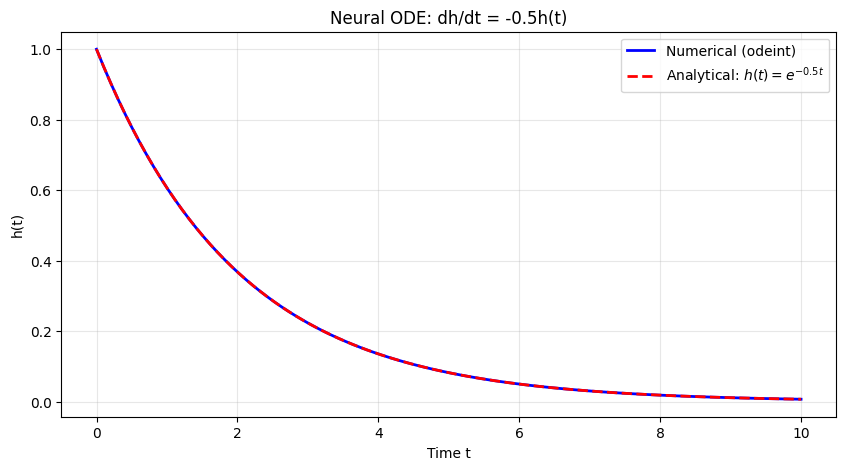


Integral verification at t=5.0:
  h(0) + ∫_0^5.0 f(h(s)) ds = 0.082085
  Analytical h(5.0) = 0.082085


In [25]:
from scipy.integrate import odeint

# Neural ODE: dh/dt = -0.5 * h(t)
# This represents a simple "neural" dynamics with learned parameter -0.5

def neural_ode(h, t, theta=-0.5):
    """Simple Neural ODE: dh/dt = theta * h(t)"""
    return theta * h

# Time span
t = np.linspace(0, 10, 100)

# Initial condition
h0 = 1.0

# Solve ODE using numerical integration (scipy.odeint uses Adams/BDF methods)
h_solution = odeint(neural_ode, h0, t)

# Analytical solution: h(t) = h0 * exp(-0.5*t)
h_analytical = h0 * np.exp(-0.5 * t)

print("Neural ODE Solution:")
print(f"  h(0) = {h0}")
print(f"  h(5) ≈ {h_solution[50, 0]:.6f} (numerical)")
print(f"  h(5) = {h_analytical[50]:.6f} (analytical)")
print(f"  h(10) ≈ {h_solution[-1, 0]:.6f} (numerical)")
print(f"  h(10) = {h_analytical[-1]:.6f} (analytical)")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t, h_solution[:, 0], 'b-', linewidth=2, label='Numerical (odeint)')
ax.plot(t, h_analytical, 'r--', linewidth=2, label='Analytical: $h(t) = e^{-0.5t}$')
ax.set_xlabel('Time t')
ax.set_ylabel('h(t)')
ax.set_title('Neural ODE: dh/dt = -0.5h(t)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Demonstrate the integral form: h(t) = h(0) + ∫_0^t f(h(s), s) ds
# For this simple case, we can verify numerically
from scipy.integrate import quad

def integrand(s, theta=-0.5):
    h_s = h0 * np.exp(theta * s)
    return theta * h_s

t_test = 5.0
integral_result, _ = quad(integrand, 0, t_test)
h_from_integral = h0 + integral_result

print(f"\nIntegral verification at t={t_test}:")
print(f"  h(0) + ∫_0^{t_test} f(h(s)) ds = {h_from_integral:.6f}")
print(f"  Analytical h({t_test}) = {h0 * np.exp(-0.5 * t_test):.6f}")

---

# Section 24: Physics-Informed Neural Networks (PINNs)

## Concept

**PINNs** embed physical laws (differential equations) into neural network training. Integration helps enforce conservation laws and boundary conditions.

## Example: Heat Equation

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

The total energy (integral of $u$ over space) should be conserved:

$$E(t) = \int_0^L u(x, t) \, dx = \text{constant}$$

## Simple Demonstration

We solve a decay equation and verify that the integral of the solution matches physical expectations.

## AI/ML Connection

PINNs are used in:
- **Climate modeling** (Navier-Stokes equations)
- **Materials science** (phase field equations)
- **Fluid dynamics** (turbulence modeling)
- **Medical imaging** (inverse problems)

In [26]:
# PINN-inspired example: Verify conservation law
# For dh/dt = -0.5*h, the "total quantity" decays exponentially
# Let's verify by integrating the solution over time

# Spatial domain (simplified 1D)
x = np.linspace(0, 1, 100)
t = np.linspace(0, 5, 50)

# Solution: u(x,t) = sin(πx) * exp(-0.5*t) (decaying spatial mode)
X, T = np.meshgrid(x, t)
U = np.sin(np.pi * X) * np.exp(-0.5 * T)

# Verify: ∫_0^1 u(x,t) dx = (2/π) * exp(-0.5*t) for each t
spatial_integral = np.trapz(U, x, axis=1)
analytical_integral = (2/np.pi) * np.exp(-0.5 * t)

print("PINN Conservation Check:")
print(f"  At t=0: Numerical ∫u dx = {spatial_integral[0]:.6f}, Analytical = {analytical_integral[0]:.6f}")
print(f"  At t=2.5: Numerical ∫u dx = {spatial_integral[25]:.6f}, Analytical = {analytical_integral[25]:.6f}")
print(f"  At t=5: Numerical ∫u dx = {spatial_integral[-1]:.6f}, Analytical = {analytical_integral[-1]:.6f}")

# Visualize the solution and its spatial integral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax1 = axes[0]
im = ax1.contourf(X, T, U, levels=20, cmap='hot')
ax1.set_xlabel('x')
ax1.set_ylabel('t')
ax1.set_title('Solution u(x,t) = sin(πx)·exp(-0.5t)')
plt.colorbar(im, ax=ax1)

# Spatial integral over time
ax2 = axes[1]
ax2.plot(t, spatial_integral, 'b-', linewidth=2, label='Numerical ∫u dx')
ax2.plot(t, analytical_integral, 'r--', linewidth=2, label='Analytical (2/π)·exp(-0.5t)')
ax2.set_xlabel('Time t')
ax2.set_ylabel('∫₀¹ u(x,t) dx')
ax2.set_title('Spatial Integral (Conservation Check)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

AttributeError: module 'numpy' has no attribute 'trapz'

---

# Section 25: Generative AI Connection

## Concept

Modern generative models rely heavily on integration:

### Diffusion Models

Diffusion models learn to reverse a noise process described by a stochastic differential equation (SDE). The probability flow requires integration over time:

$$p(x_t) = \int p(x_t | x_{t-1}) \, p(x_{t-1}) \, dx_{t-1}$$

### Variational Inference

The **Evidence Lower Bound (ELBO)** involves integrals:

$$\text{ELBO} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - \text{KL}(q(z|x) || p(z))$$

### Continuous Probability Distributions

Normalizing flows use the **change of variables formula**:

$$p_X(x) = p_Z(f(x)) \left| \det \frac{\partial f}{\partial x} \right|$$

which requires integration for normalization.

## AI/ML Connection

Integration powers:
- **Stable Diffusion** (sampling via integration)
- **VAEs** (latent space probability)
- **Flow-based models** (density estimation)
- **Score matching** (learning data distributions)

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_14216\2083317386.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_14216\2083317386.py:14: RuntimeWarning: invalid value encountered in divide
  return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)


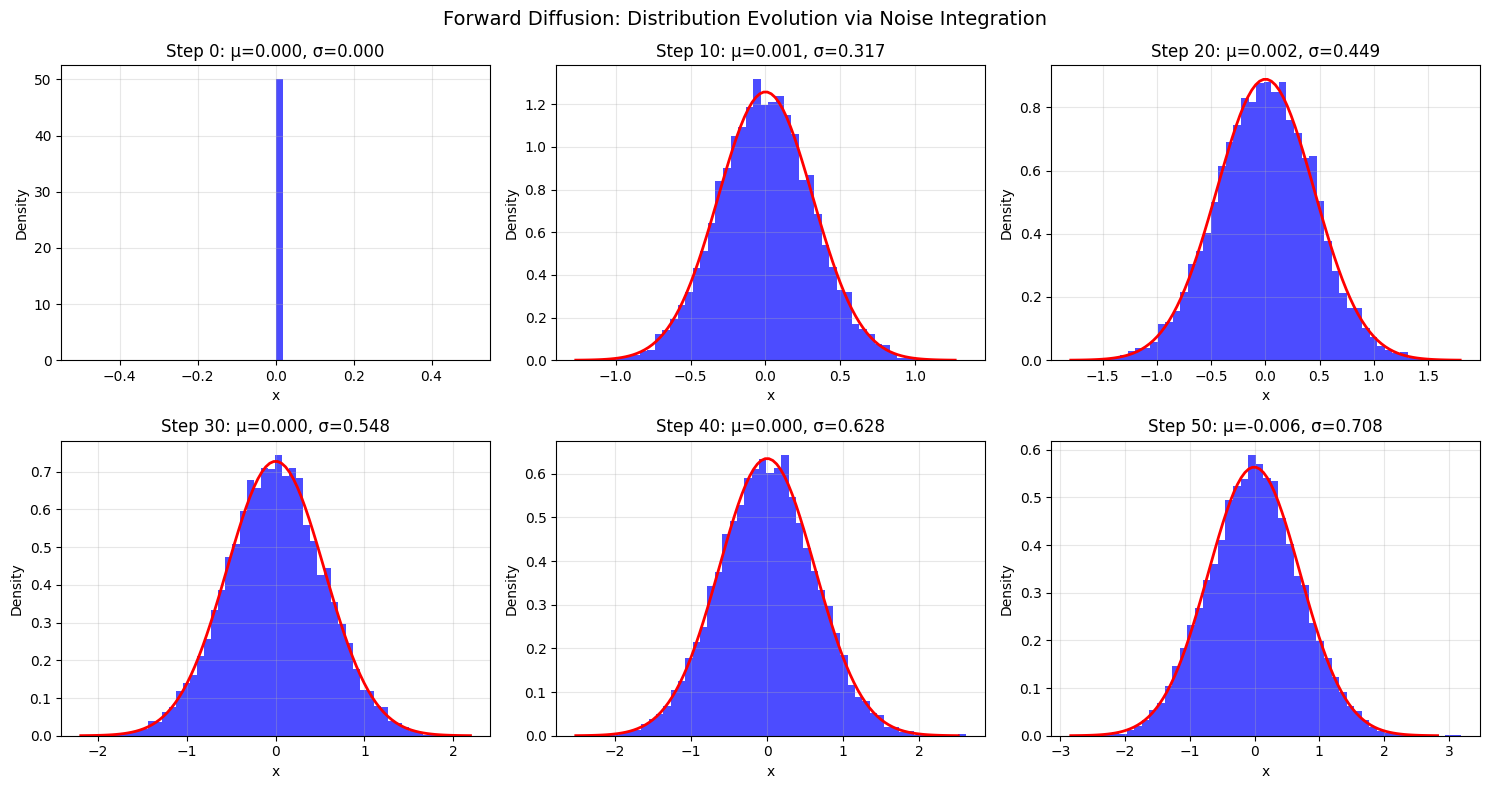

Diffusion Process Summary:
  Initial: Point mass at 0
  Final: Approximately N(0, 0.708)
  Theoretical σ after 50 steps: 0.707
  Actual σ: 0.708

Variational Inference Example:
  KL(q||p(z)) = 10.1627
  This is the penalty for q being different from the prior


In [27]:
# Generative AI: Simple Diffusion-like Process
# Demonstrate how a distribution evolves through integration steps

# Start with a point mass at x=0 (deterministic)
# Add Gaussian noise at each step: x_{t+1} = x_t + ε, ε ~ N(0, σ²)
# This is the forward diffusion process

np.random.seed(42)

# Parameters
n_samples = 10000
n_steps = 50
sigma = 0.1

# Initial distribution: point mass at 0
samples = np.zeros(n_samples)

# Forward diffusion: integrate noise over time
history = [samples.copy()]
for step in range(n_steps):
    samples = samples + np.random.normal(0, sigma, n_samples)
    if step % 10 == 9:
        history.append(samples.copy())

# Plot evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (samples_i, ax) in enumerate(zip(history, axes)):
    ax.hist(samples_i, bins=50, density=True, alpha=0.7, color='blue')

    # Fit Gaussian and overlay
    mu_est = np.mean(samples_i)
    sigma_est = np.std(samples_i)
    x_range = np.linspace(mu_est - 4*sigma_est, mu_est + 4*sigma_est, 100)
    ax.plot(x_range, normal_pdf_param(x_range, mu_est, sigma_est), 'r-', linewidth=2)

    ax.set_title(f'Step {i*10}: μ={mu_est:.3f}, σ={sigma_est:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

plt.suptitle('Forward Diffusion: Distribution Evolution via Noise Integration', fontsize=14)
plt.tight_layout()
plt.show()

print("Diffusion Process Summary:")
print(f"  Initial: Point mass at 0")
print(f"  Final: Approximately N(0, {np.std(history[-1]):.3f})")
print(f"  Theoretical σ after {n_steps} steps: {sigma * np.sqrt(n_steps):.3f}")
print(f"  Actual σ: {np.std(history[-1]):.3f}")

# Variational Inference: Simple ELBO demonstration
# True posterior: N(5, 1)
# Approximate posterior: q(z) = N(μ, σ²)
# ELBO = E_q[log p(x|z)] - KL(q||p(z))

mu_true, sigma_true = 5, 1
mu_q, sigma_q = 4.5, 1.2  # Approximate

# Compute KL divergence analytically: KL(N(μ_q, σ_q²) || N(0, 1))
kl_div = 0.5 * (sigma_q**2 + mu_q**2 - 1 - np.log(sigma_q**2))
print(f"\nVariational Inference Example:")
print(f"  KL(q||p(z)) = {kl_div:.4f}")
print(f"  This is the penalty for q being different from the prior")

---

# Section 26: Mini Project — Numerical Integration Toolkit

## Objective

Build a comprehensive toolkit that compares multiple numerical integration methods on user-defined functions.

## Methods Implemented

1. Rectangle Rule
2. Midpoint Rule
3. Trapezoidal Rule
4. Simpson's Rule
5. SciPy Integration (adaptive)

## Features

- Accept any Python function
- Compare accuracy and convergence
- Visualize results

In [28]:
class IntegrationToolkit:
    """A comprehensive numerical integration toolkit."""

    def __init__(self, f, a, b):
        self.f = f
        self.a = a
        self.b = b
        self.exact = None

    def set_exact(self, exact_value):
        """Set the exact value for error comparison."""
        self.exact = exact_value

    def rectangle(self, n=100):
        """Rectangle (left endpoint) rule."""
        dx = (self.b - self.a) / n
        total = sum(self.f(self.a + i * dx) for i in range(n))
        return total * dx

    def midpoint(self, n=100):
        """Midpoint rule."""
        dx = (self.b - self.a) / n
        total = sum(self.f(self.a + (i + 0.5) * dx) for i in range(n))
        return total * dx

    def trapezoidal(self, n=100):
        """Trapezoidal rule."""
        dx = (self.b - self.a) / n
        total = 0.5 * (self.f(self.a) + self.f(self.b))
        total += sum(self.f(self.a + i * dx) for i in range(1, n))
        return total * dx

    def simpson(self, n=100):
        """Simpson's rule (n must be even)."""
        if n % 2 == 1:
            n += 1
        dx = (self.b - self.a) / n
        total = self.f(self.a) + self.f(self.b)

        for i in range(1, n):
            coeff = 4 if i % 2 == 1 else 2
            total += coeff * self.f(self.a + i * dx)

        return total * dx / 3

    def scipy_quad(self):
        """SciPy adaptive quadrature."""
        result, error = sci_integrate.quad(self.f, self.a, self.b)
        return result

    def compare(self, n=100):
        """Compare all methods."""
        methods = {
            'Rectangle': self.rectangle(n),
            'Midpoint': self.midpoint(n),
            'Trapezoidal': self.trapezoidal(n),
            'Simpson': self.simpson(n),
            'SciPy': self.scipy_quad()
        }

        if self.exact is not None:
            for name, value in methods.items():
                methods[name] = {
                    'Result': value,
                    'Error': abs(value - self.exact)
                }

        return methods

# Test the toolkit on f(x) = x^2 on [0, 2]
toolkit = IntegrationToolkit(lambda x: x**2, 0, 2)
toolkit.set_exact(8/3)

print("=== Integration Toolkit: f(x) = x² on [0, 2] ===")
print(f"Exact value: {toolkit.exact:.10f}\n")

comparison = toolkit.compare(n=10)
for method, result in comparison.items():
    print(f"{method:12s}: Result = {result['Result']:.10f}, Error = {result['Error']:.2e}")

# Test on a more complex function: f(x) = e^(-x^2) on [0, 2]
print("\n=== Integration Toolkit: f(x) = e^(-x²) on [0, 2] ===")
toolkit2 = IntegrationToolkit(lambda x: np.exp(-x**2), 0, 2)
toolkit2.set_exact(0.8820813907624217)  # Known value: sqrt(π)/2 * erf(2)

comparison2 = toolkit2.compare(n=20)
for method, result in comparison2.items():
    print(f"{method:12s}: Result = {result['Result']:.10f}, Error = {result['Error']:.2e}")

=== Integration Toolkit: f(x) = x² on [0, 2] ===
Exact value: 2.6666666667

Rectangle   : Result = 2.2800000000, Error = 3.87e-01
Midpoint    : Result = 2.6600000000, Error = 6.67e-03
Trapezoidal : Result = 2.6800000000, Error = 1.33e-02
Simpson     : Result = 2.6666666667, Error = 0.00e+00
SciPy       : Result = 2.6666666667, Error = 4.44e-16

=== Integration Toolkit: f(x) = e^(-x²) on [0, 2] ===
Rectangle   : Result = 0.9311046585, Error = 4.90e-02
Midpoint    : Result = 0.8821118278, Error = 3.04e-05
Trapezoidal : Result = 0.8820204404, Error = 6.10e-05
Simpson     : Result = 0.8820809836, Error = 4.07e-07
SciPy       : Result = 0.8820813908, Error = 1.11e-16


---

# Section 27: Performance Comparison Table

## Objective

Create a comprehensive comparison table using Pandas DataFrame.

## Test Function

$$f(x) = e^{-x^2} \quad \text{on} \quad [0, 2]$$

This is the integrand of the **error function**, which has no elementary closed form.

=== Full Results DataFrame ===
 n  Rectangle_Result  Rectangle_Error  Midpoint_Result  Midpoint_Error  Trapezoidal_Result  Trapezoidal_Error  Simpson_Result  Simpson_Error  SciPy_Result  SciPy_Error
 4          1.126040         0.243958         0.882789        0.000708            0.880619           0.001463        0.881812   2.689655e-04      0.882081 1.110223e-16
 8          1.004414         0.122333         0.882269        0.000187            0.881704           0.000378        0.882066   1.588036e-05      0.882081 1.110223e-16
16          0.943342         0.061260         0.882129        0.000047            0.881986           0.000095        0.882080   9.941854e-07      0.882081 1.110223e-16
32          0.912735         0.030654         0.882093        0.000012            0.882058           0.000024        0.882081   6.211607e-08      0.882081 1.110223e-16
64          0.897414         0.015333         0.882084        0.000003            0.882075           0.000006        0.882081   3

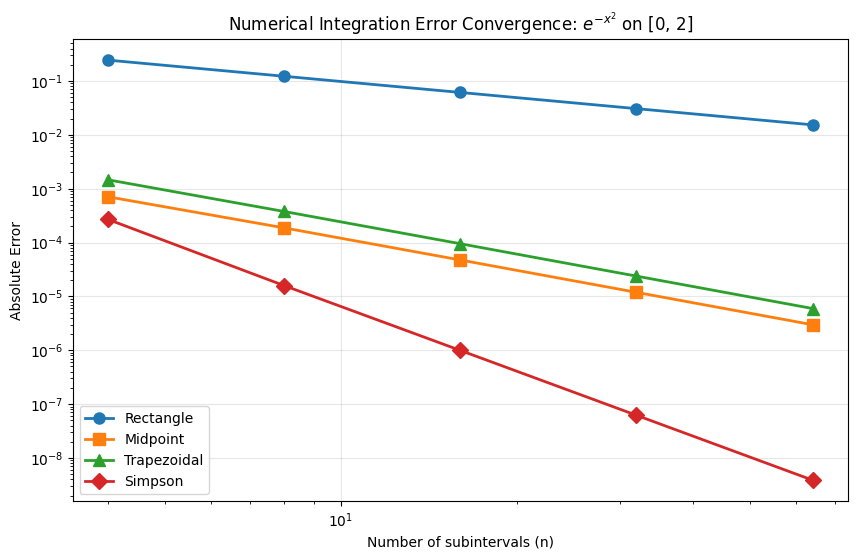

In [29]:
# Comprehensive performance comparison
f_test = lambda x: np.exp(-x**2)
a, b = 0, 2
exact = 0.8820813907624217

n_values = [4, 8, 16, 32, 64]
all_results = []

for n in n_values:
    toolkit = IntegrationToolkit(f_test, a, b)
    toolkit.set_exact(exact)
    comp = toolkit.compare(n=n)

    row = {'n': n}
    for method, data in comp.items():
        row[f'{method}_Result'] = data['Result']
        row[f'{method}_Error'] = data['Error']
    all_results.append(row)

df_results = pd.DataFrame(all_results)
print("=== Full Results DataFrame ===")
print(df_results.to_string(index=False))

# Create a clean comparison table for n=32
print("\n=== Comparison for n=32 ===")
toolkit_final = IntegrationToolkit(f_test, a, b)
toolkit_final.set_exact(exact)
comp_final = toolkit_final.compare(n=32)

table_data = {
    'Method': [],
    'Result': [],
    'Error': [],
    'Accuracy': []
}

for method, data in comp_final.items():
    table_data['Method'].append(method)
    table_data['Result'].append(f"{data['Result']:.8f}")
    table_data['Error'].append(f"{data['Error']:.2e}")
    # Accuracy rating
    if data['Error'] < 1e-10:
        table_data['Accuracy'].append('★★★★★')
    elif data['Error'] < 1e-6:
        table_data['Accuracy'].append('★★★★☆')
    elif data['Error'] < 1e-3:
        table_data['Accuracy'].append('★★★☆☆')
    else:
        table_data['Accuracy'].append('★★☆☆☆')

df_table = pd.DataFrame(table_data)
print(df_table.to_string(index=False))

# Visualize error convergence
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
methods_plot = ['Rectangle', 'Midpoint', 'Trapezoidal', 'Simpson']
markers = ['o', 's', '^', 'D']

for method, marker in zip(methods_plot, markers):
    errors = [row[f'{method}_Error'] for row in all_results]
    ax.loglog(n_values, errors, marker=marker, label=method, linewidth=2, markersize=8)

ax.set_xlabel('Number of subintervals (n)')
ax.set_ylabel('Absolute Error')
ax.set_title('Numerical Integration Error Convergence: $e^{-x^2}$ on [0, 2]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---

# Section 28: AI Applications Summary

## Where Integration Appears in Modern AI

### 1. Probability Theory
- Normalizing probability distributions
- Computing cumulative probabilities
- Expected values and moments

### 2. Bayesian Learning
- Marginal likelihood (evidence)
- Posterior predictive distributions
- Bayesian model averaging

### 3. Reinforcement Learning
- Expected cumulative reward
- Value function estimation
- Policy gradient theorems

### 4. Neural ODEs
- Continuous-time neural networks
- Adjoint method for backpropagation
- Normalizing flows

### 5. Physics-Informed Neural Networks
- Enforcing conservation laws
- Solving PDEs with deep learning
- Inverse problem solving

### 6. Generative AI
- Diffusion models (SDE integration)
- Variational inference (ELBO)
- Normalizing flows (change of variables)

## Key Takeaway

> **Integration is not just a mathematical tool — it is the computational engine behind probability, continuous learning, and modern generative AI systems.**

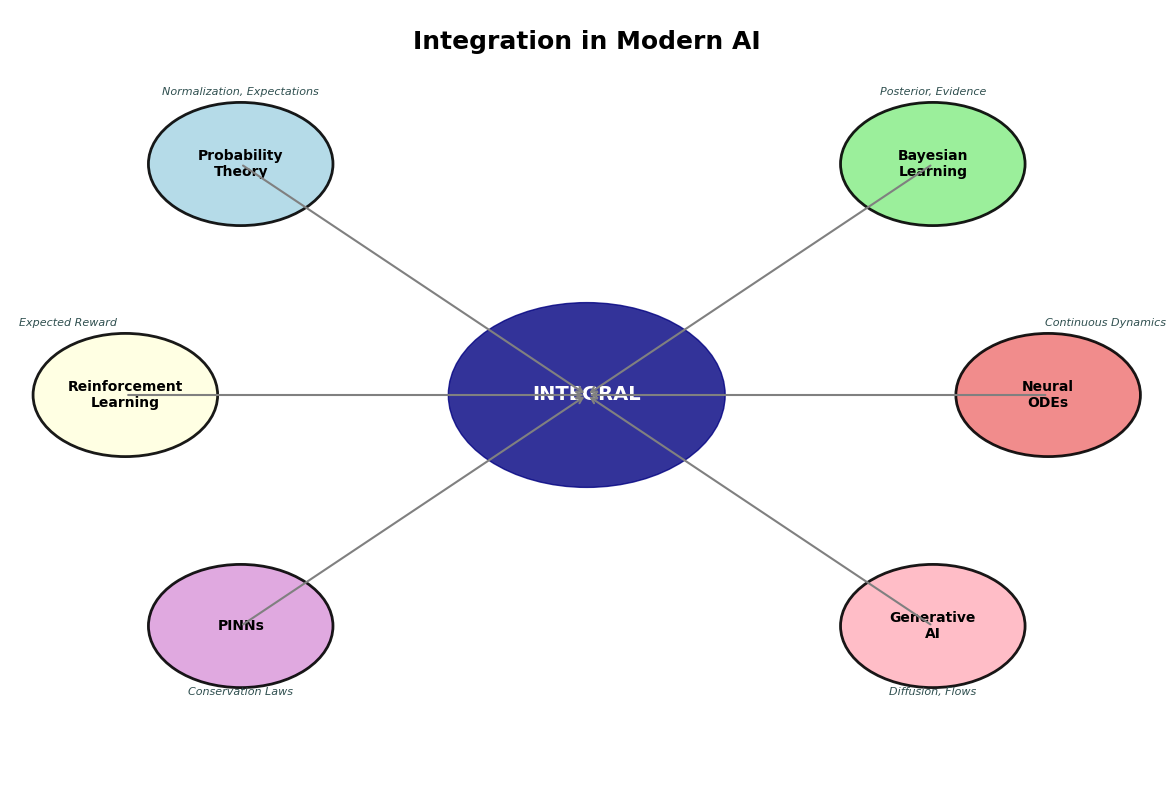

Integration connects all major AI paradigms through the language of accumulation and expectation.


In [30]:
# Summary visualization: Integration in AI Pipeline
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Integration in Modern AI', fontsize=18, fontweight='bold', ha='center')

# Central node
central = plt.Circle((5, 5), 1.2, color='navy', alpha=0.8)
ax.add_patch(central)
ax.text(5, 5, 'INTEGRAL', fontsize=14, fontweight='bold', color='white', ha='center', va='center')

# Application nodes
apps = [
    (2, 8, 'Probability\nTheory', 'lightblue'),
    (8, 8, 'Bayesian\nLearning', 'lightgreen'),
    (1, 5, 'Reinforcement\nLearning', 'lightyellow'),
    (9, 5, 'Neural\nODEs', 'lightcoral'),
    (2, 2, 'PINNs', 'plum'),
    (8, 2, 'Generative\nAI', 'lightpink')
]

for x, y, label, color in apps:
    circle = plt.Circle((x, y), 0.8, color=color, alpha=0.9, ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, label, fontsize=10, ha='center', va='center', fontweight='bold')
    # Draw arrow to center
    ax.annotate('', xy=(5, 5), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Add use cases
use_cases = [
    (2, 8.9, 'Normalization, Expectations'),
    (8, 8.9, 'Posterior, Evidence'),
    (0.5, 5.9, 'Expected Reward'),
    (9.5, 5.9, 'Continuous Dynamics'),
    (2, 1.1, 'Conservation Laws'),
    (8, 1.1, 'Diffusion, Flows')
]

for x, y, text in use_cases:
    ax.text(x, y, text, fontsize=8, ha='center', style='italic', color='darkslategray')

plt.tight_layout()
plt.show()

print("Integration connects all major AI paradigms through the language of accumulation and expectation.")

---

# Section 29: Summary

## What We Learned

### ✅ Core Calculus
- **Antiderivatives** — reverse of differentiation
- **Indefinite Integrals** — families of antiderivatives ($+C$)
- **Definite Integrals** — accumulated quantity, area under curves
- **Fundamental Theorem of Calculus** — connects differentiation and integration

### ✅ Numerical Methods
- **Riemann Sums** — approximating with rectangles
- **Rectangle, Midpoint, Trapezoidal Rules** — basic numerical methods
- **Simpson's Rule** — higher accuracy with parabolic approximation
- **SciPy Integration** — adaptive, high-precision numerical integration

### ✅ Multivariable Integration
- **Double Integrals** — volume under surfaces
- **Triple Integrals** — accumulated quantity in 3D space

### ✅ Probability & Statistics
- **Probability Density Functions** — normalization via integration
- **Expected Values** — mean of continuous distributions
- **Gaussian Distribution** — the cornerstone of statistical ML

### ✅ Modern AI Applications
- **Bayesian Learning** — posterior normalization, evidence computation
- **Reinforcement Learning** — expected cumulative reward
- **Neural ODEs** — continuous-time deep learning
- **Physics-Informed Neural Networks** — enforcing physical laws
- **Generative AI** — diffusion models, variational inference, normalizing flows

## Final Insight

> **Integrals are the mathematical foundation of accumulation, probability, continuous systems, and many modern AI algorithms. From normalizing a probability distribution to solving continuous-time neural networks, integration is the silent engine powering machine learning.**

## Next Steps

1. Practice symbolic integration with SymPy on complex functions
2. Implement numerical integration from scratch for deeper understanding
3. Explore Bayesian inference libraries (PyMC, Stan)
4. Experiment with Neural ODE frameworks (torchdiffeq)
5. Apply integration concepts to your own ML projects

---

**Happy Learning! 🚀**